In [1]:
from collect import *
from extract import *
from run_tests import *

In [6]:
collect(11_000_000, "data.bin")

Найден порт: COM5 - Устройство с последовательным интерфейсом USB (COM5)
Сбор 11,000,000 отсчетов... (Ctrl+C для остановки)
  Прогресс: 11,001,856/11,000,000 (100%)

Собрано: 11,000,000 отсчетов
Время сбора: 54.9 сек
Скорость: 200,283 отсчетов/сек
Файл сохранён: data.bin (Размер: 20.98 МБ)

Оценки энтропии (NIST SP 800-90B):
MCV: 0.9757 бит/символ
Collision: 1.0000 бит/символ
Markov: 0.9377 бит/символ

Мин-энтропия: 0.9377 бит/бит
Рекомендуемый коэффициент сжатия: ≤ 2.28


In [7]:
raw_bits = load_data_bin("data.bin")
extracted_bits = arx_extract(raw_bits, 5000000, 2)
run_nist(extracted_bits)

Загружено 11000000 отсчетов из data.bin.
Длина последовательности: 5000000 бит
Распределение: 0.5002 (1) / 0.4998 (0)
----------------------------------------------------------------------
Название теста                                | P-value    | Статус
----------------------------------------------------------------------
1. Frequency (Monobit) Test                   | 0.343538   | Пройден
2. Block Frequency Test                       | 0.694452   | Пройден
3. Runs Test                                  | 0.147233   | Пройден
4. Longest Run of Ones in a Block             | 0.800616   | Пройден
5. Binary Matrix Rank Test                    | 0.723636   | Пройден
6. Spectral (DFT) Test                        | 0.281721   | Пройден
7. Non-overlapping Template (mean P)          | 0.681531   | Пройден
8. Overlapping Template Matching (m=9)        | 0.505873   | Пройден
9. Maurer's Universal Test                    | 0.910179   | Пройден
10. Linear Complexity Test                    | 0.5

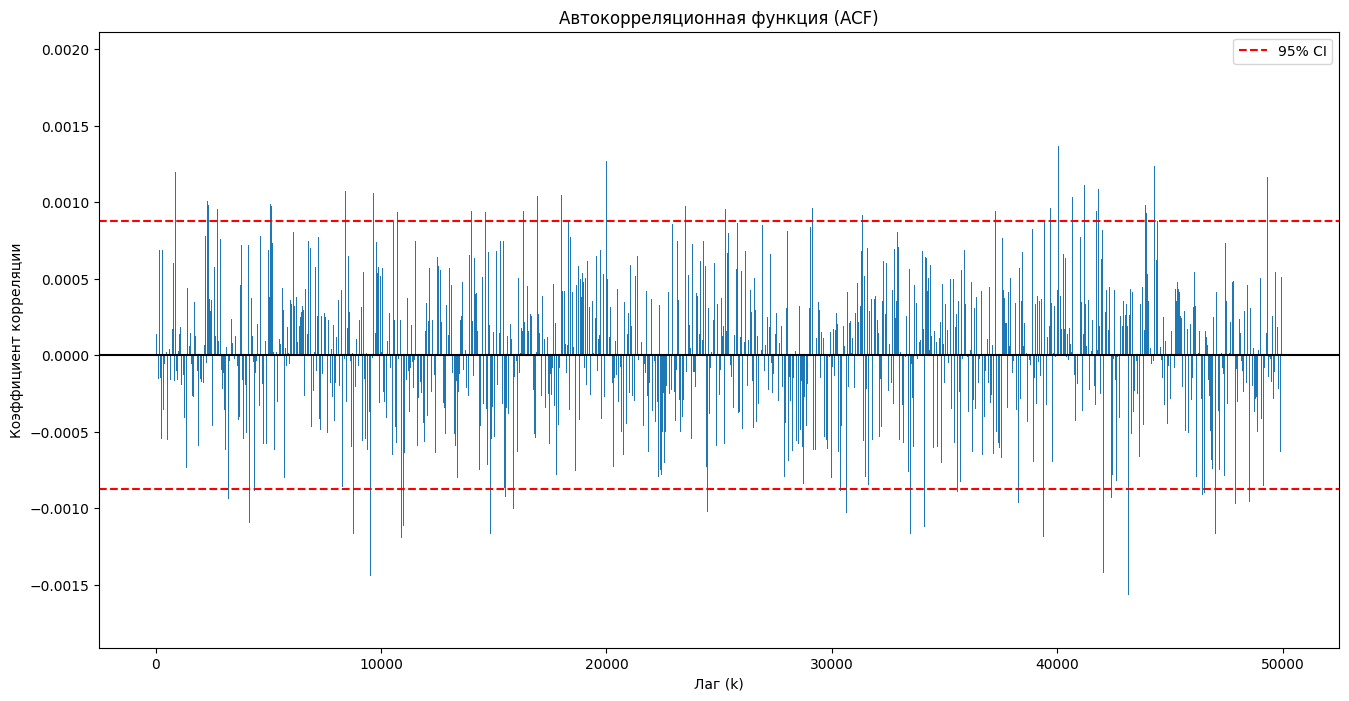

In [12]:
def plot_acf1(bits, max_lag=50):
    """Визуализация ACF"""
    bits = np.asarray(bits, dtype=int)
    X = 2 * bits - 1
    n = len(X)
    
    lags = range(1, max_lag + 1)
    acf = [np.dot(X[:n-k], X[k:]) / n for k in lags]
    
    plt.figure(figsize=(16, 8))
    plt.bar(lags, acf, width=0.8)
    plt.axhline(y=0, color='black', linestyle='-')
    plt.axhline(y=1.96 / np.sqrt(n), color='red', linestyle='--', label='95% CI')
    plt.axhline(y=-1.96 / np.sqrt(n), color='red', linestyle='--')
    plt.title('Автокорреляционная функция (ACF)')
    plt.xlabel('Лаг (k)')
    plt.ylabel('Коэффициент корреляции')
    plt.legend()
    plt.show()

plot_acf1(extracted_bits, 50000)